In [1]:
import pandas as pd
import numpy as np
import keras
import tensorflow as tf
import shap
import matplotlib.pyplot as plt
import h5py

seed=42

# 1. Data processing

In [2]:
from google.colab import drive
drive.mount('/content/drive')
f = h5py.File('/content/drive/MyDrive/Table_TNG300_snapshot99_SubhalosProp_HaloProp.hdf5', 'r')
f.keys()

Mounted at /content/drive


<KeysViewHDF5 ['GroupPos_halo', 'M200_halo', 'Spin_halo', 'SubGroupSFR', 'SubGroupStellarPhotom_g', 'SubGroupStellarPhotom_i', 'SubGroupStellarPhotom_r', 'SubGroupStellarPhotom_z', 'SubhaloCM', 'SubhaloGrNr', 'SubhaloId', 'SubhaloMassType', 'SubhaloPos', 'b1', 'b2', 'c200_halo', 'd3_halo', 'd5_halo', 'd8_halo', 'd_minima', 'd_node', 'd_saddle_1', 'd_saddle_2', 'd_skel', 'zform_halo']>

In [3]:
GrNr = np.asarray(f['SubhaloGrNr'])
mass = np.asarray(f['SubhaloMassType'][:,4])
halo_mass = np.asarray(f['M200_halo'])
d3 = np.asarray(f['d3_halo'])
d5 = np.asarray(f['d5_halo'])
d8 = np.asarray(f['d8_halo'])
c_200= np.asarray(f['c200_halo'])
z = np.asarray(f['zform_halo'])
d_min = np.asarray(f['d_minima'])
d_node = np.asarray(f['d_node'])
d_saddle_1 = np.asarray(f['d_saddle_1'])
d_saddle_2 = np.asarray(f['d_saddle_2'])
d_skel = np.asarray(f['d_skel'])
b1 = np.asarray(f['b1'])
spin = np.asarray(f['Spin_halo'])

In [4]:
indices_cambio = np.unique(GrNr, return_index=True)[1]
mass_filtrada = mass[indices_cambio]
halo_mass_filtrada = halo_mass[indices_cambio]
d3 = d3[indices_cambio]
d5 = d5[indices_cambio]
d8 = d8[indices_cambio]
c_200= c_200[indices_cambio]
z = z[indices_cambio]
d_min = d_min[indices_cambio]
d_node = d_node[indices_cambio]
d_saddle_1 = d_saddle_1[indices_cambio]
d_saddle_2 = d_saddle_2[indices_cambio]
d_skel = d_skel[indices_cambio]
b1 = b1[indices_cambio]
spin = spin[indices_cambio]

indices_comunes=np.where((np.log10(mass_filtrada) >8.75)*(np.log10(halo_mass_filtrada) >10.5))[0]

mass_filtrada = np.log10(mass_filtrada[indices_comunes])
halo_mass_filtrada = np.log10(halo_mass_filtrada[indices_comunes])
d3 = d3[indices_comunes]
d5 = d5[indices_comunes]
d8 = d8[indices_comunes]
c_200= c_200[indices_comunes]
z = z[indices_comunes]
d_min = d_min[indices_comunes]
d_node = d_node[indices_comunes]
d_saddle_1 = d_saddle_1[indices_comunes]
d_saddle_2 = d_saddle_2[indices_comunes]
d_skel = d_skel[indices_comunes]
b1 = b1[indices_comunes]
spin = spin[indices_comunes]

/tmp/ipykernel_1669/4160979324.py:17: RuntimeWarning: invalid value encountered in log10
  indices_comunes=np.where((np.log10(mass_filtrada) >8.75)*(np.log10(halo_mass_filtrada) >10.5))[0]


In [5]:
X = np.column_stack((halo_mass_filtrada,d3, d5, d8, c_200, z, spin, d_min, d_node, d_saddle_1,d_saddle_2, d_skel))
y = b1.reshape(-1, 1)

In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

scaler = StandardScaler()
y_norm = scaler.fit_transform(y)

X_norm.shape, y_norm.shape

((174607, 12), (174607, 1))

In [7]:

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_norm,y_norm,test_size=0.30,random_state=seed)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.20, random_state=seed)
X_train.shape, X_val.shape, X_test.shape

((97779, 12), (24445, 12), (52383, 12))

# 2. Model loading

In [ ]:
### --- Download previously trained model
#!gdown 'https://drive.google.com/file/d/1WT0bDVNxaHRCoFrz_DBXHOwtix6R4WKT/view?usp=sharing'

In [8]:
### --- load model

model = keras.saving.load_model('Resnet50Conv1d_fullmodel.keras')
#model.summary() #uncomment this line to see network layers

# 3. SHAP Explanations

In [9]:
def predict_for_shap(x_2d):
    x_3d = tf.cast(np.asarray(x_2d).reshape((-1, X_train.shape[1], 1)), tf.float32)
    return model(x_3d, training=False).numpy().reshape(-1)

rng = np.random.default_rng(42)
background_idx = rng.choice(X_train.shape[0], size=500, replace=False)
explain_idx    = rng.choice(X_test.shape[0],  size=1800, replace=False)

X_background = X_train[background_idx]
X_explain    = X_test[explain_idx]

explainer   = shap.KernelExplainer(predict_for_shap, X_background)
shap_values = explainer.shap_values(X_explain, nsamples=120)

if isinstance(shap_values, list):
    shap_values = shap_values[0]

features = ['halo_mass', 'd3', 'd5', 'd8', 'c_200', 'z', 'spin',
            'd_min', 'd_node', 'd_saddle_1', 'd_saddle_2', 'd_skel']

  0%|          | 0/1800 [00:00<?, ?it/s]

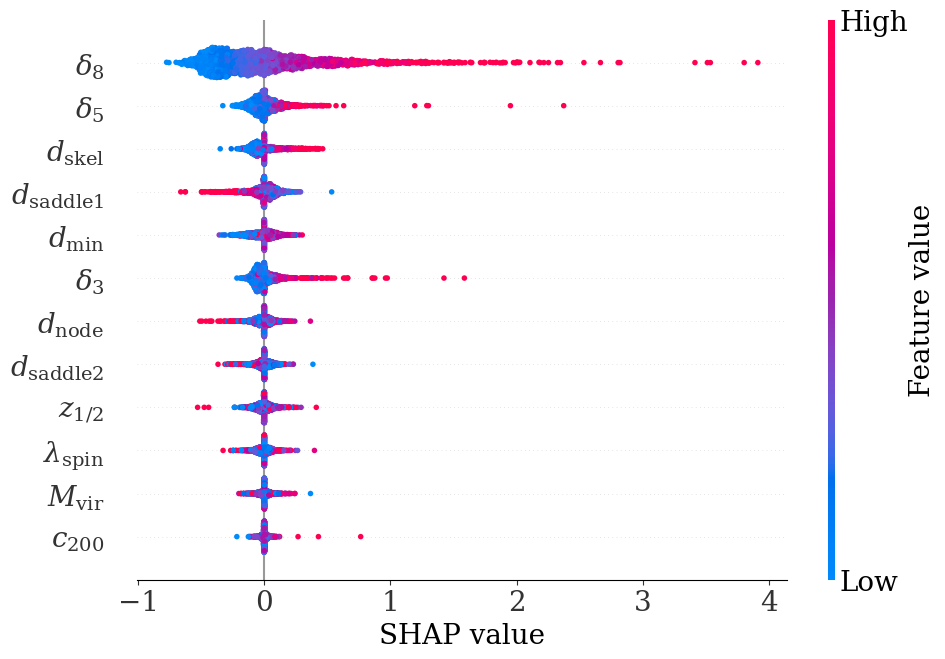

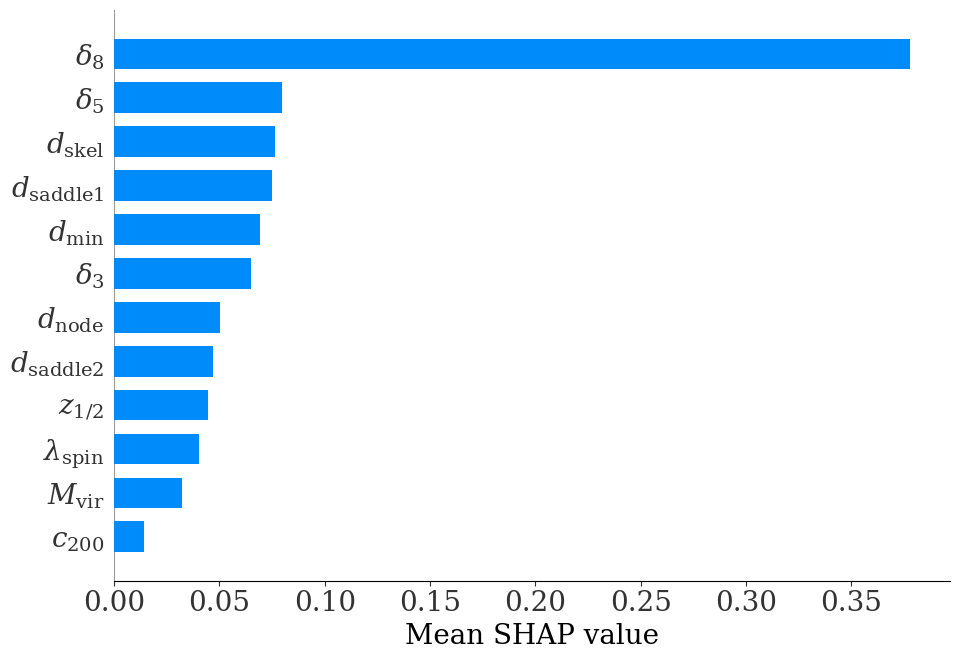

In [22]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 20,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
})

plt.rcParams["font.family"] = "DejaVu Serif"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams["mathtext.rm"] = "DejaVu Serif"
plt.rcParams["mathtext.it"] = "DejaVu Serif:italic"
plt.rcParams["mathtext.bf"] = "DejaVu Serif:bold"

feature_names = [
    r'$M_{\rm vir}$',
    r'$\delta_3$',
    r'$\delta_5$',
    r'$\delta_8$',
    r'$c_{200}$',
    r'$z_{1/2}$',
    r'$\lambda_{\rm spin}$',
    r'$d_{\rm min}$',
    r'$d_{\rm node}$',
    r'$d_{\rm saddle 1}$',
    r'$d_{\rm saddle 2}$',
    r'$d_{\rm skel}$'
]

shap.summary_plot(
    shap_values,
    X_explain,
    feature_names=feature_names,
    max_display=12,
    show=False
)

fig = plt.gcf()
ax = plt.gca()

ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)

plt.xlabel("SHAP value", fontsize=20)

# Colorbar
cbar_ax = fig.axes[-1]
cbar_ax.tick_params(labelsize=20)
cbar_ax.set_ylabel("Feature value", fontsize=20)

plt.gcf().set_size_inches(10, 7)
plt.tight_layout()
plt.savefig('shap_waterfall_plot.png')
plt.show()

shap.summary_plot(
    shap_values,
    X_explain,
    feature_names=feature_names,
    plot_type="bar",
    max_display=12,
    show=False
)

ax = plt.gca()

ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)

plt.xlabel("Mean SHAP value", fontsize=20)

plt.gcf().set_size_inches(10, 7)
plt.tight_layout()
plt.savefig('shap_bar_plot.png')
plt.show()

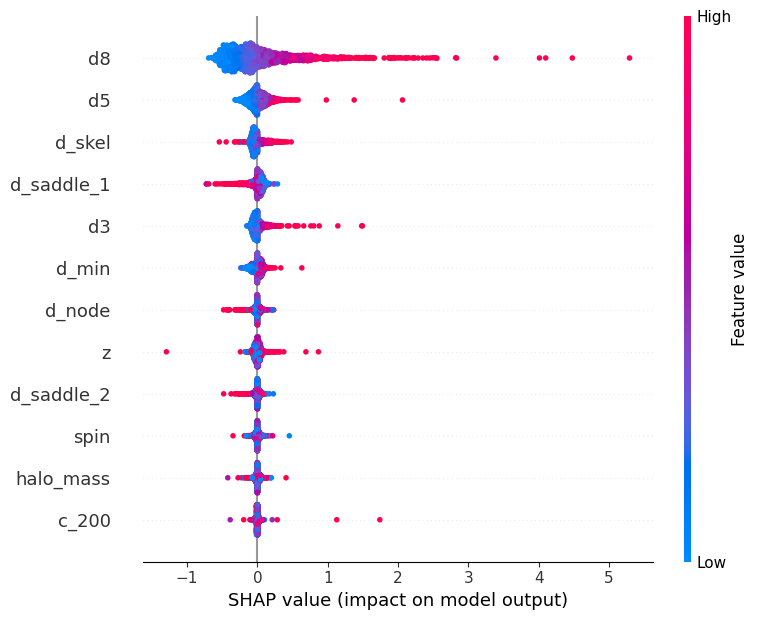

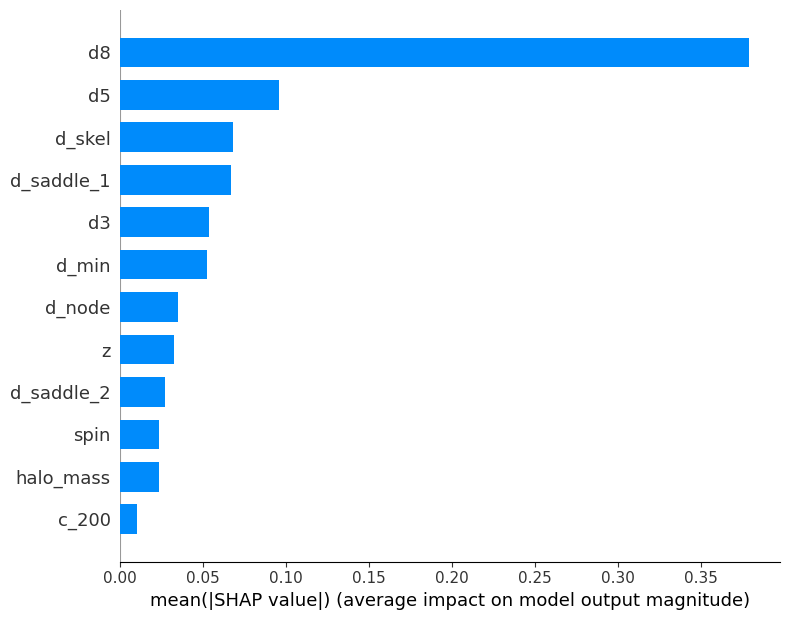

In [ ]:
# Global feature importance — beeswarm
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_explain, feature_names=features, show=True)

# Global feature importance — bar chart
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_explain, feature_names=features, plot_type='bar', show=True)

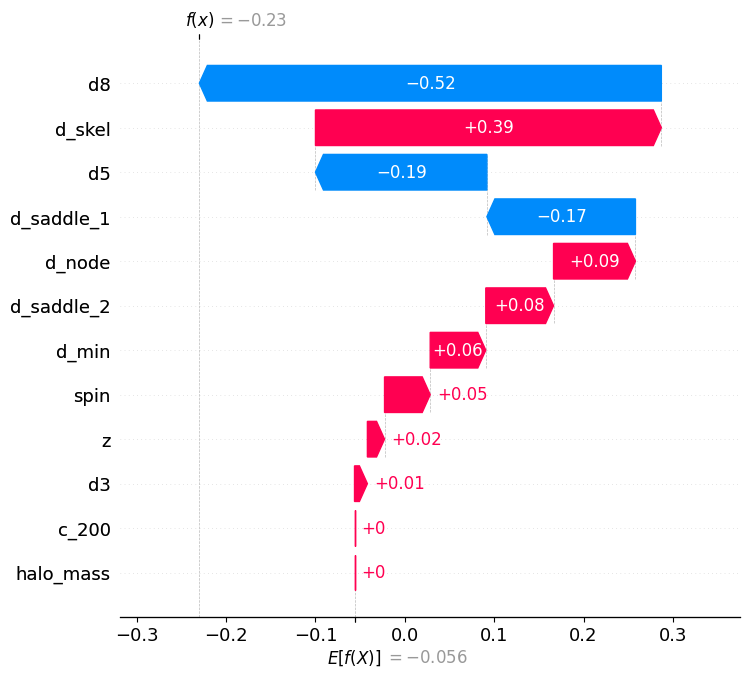

In [ ]:
# Local explanation — waterfall for a single prediction
sample_id = 500
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[sample_id],
    feature_names=features,
    max_display=12
)

In [ ]:
features = ['halo_mass', 'd3', 'd5', 'd8', 'c_200', 'z', 'spin',
            'd_min', 'd_node', 'd_saddle_1', 'd_saddle_2', 'd_skel']

In [ ]:
# === Dependencias + descubrimiento causal (PC) + fuerza causal (IDA) ===
%pip install -q causal-learn networkx
import networkx as nx
from sklearn.linear_model import LinearRegression
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.cit import fisherz,kci, fastkci
from tqdm import tqdm

n_features = X_train.shape[1]
data_full  = np.column_stack([X_train, y_train.reshape(-1)])   # features + target (espacio escalado)
node_names = features + ['b1']

# --- PC: grafo causal sobre features + target (test Fisher-Z) ---
cg = pc(data_full, alpha=0.05, indep_test=fastkci, show_progress=True)

def cpdag_to_digraph(A, names, target='b1'):
    """Convención causal-learn: i->j  si  A[i,j]==-1 y A[j,i]==1. Aristas no dirigidas (ambas -1)
    se orientan por índice => extensión DAG consistente (aproximación práctica a la clase de
    equivalencia que usa IDA). El target se fuerza como SINK: explicamos un modelo que predice
    el target A PARTIR de las features, así que las features pueden causar el target, no al revés."""
    n = len(names); G = nx.DiGraph(); G.add_nodes_from(names)
    for i in range(n):
        for j in range(i + 1, n):
            a, b = A[i, j], A[j, i]
            if a == 0 and b == 0: continue
            ni, nj = names[i], names[j]
            if target in (ni, nj):                                  # feature -> target
                u, v = (ni, nj) if nj == target else (nj, ni); G.add_edge(u, v)
            elif a == -1 and b == 1:  G.add_edge(ni, nj)
            elif a == 1 and b == -1:  G.add_edge(nj, ni)
            else:                     G.add_edge(ni, nj)            # no dirigida/bidirigida -> por índice
    if not nx.is_directed_acyclic_graph(G):                         # seguridad: romper ciclos por índice
        idx = {nm: k for k, nm in enumerate(names)}
        G = nx.DiGraph((u, v) for u, v in G.edges() if idx[u] < idx[v]); G.add_nodes_from(names)
    return G

G_full = cpdag_to_digraph(cg.G.graph, node_names)
print('¿DAG?', nx.is_directed_acyclic_graph(G_full), '| nº aristas:', G_full.number_of_edges())

# --- IDA (vía regresión): peso de arista = coef. estructural; efecto total W_i sobre b1 (Ecs. 7-8) ---
def _edge_weights(G, data, names):
    idx = {nm: k for k, nm in enumerate(names)}; w = {}
    for child in G.nodes:
        pa = list(G.predecessors(child))
        if not pa: continue
        coef = LinearRegression().fit(data[:, [idx[p] for p in pa]], data[:, idx[child]]).coef_
        for p, c in zip(pa, coef): w[(p, child)] = float(c)
    return w

def _total_effect(G, w, src, tgt):
    tot = 0.0
    for path in nx.all_simple_paths(G, src, tgt):                   # suma sobre caminos simples
        prod = 1.0
        for a, b in zip(path[:-1], path[1:]): prod *= w.get((a, b), 0.0)
        tot += prod
    return tot

edge_w = _edge_weights(G_full, data_full, node_names)
W = np.array([_total_effect(G_full, edge_w, f, 'b1') for f in features])
if np.abs(W).sum() < 1e-12:                                         # fallback: ninguna feature llega a b1
    print('AVISO: ninguna feature alcanza b1 en el grafo -> gamma uniforme')
    gamma = np.ones(n_features) / n_features
else:
    gamma = np.abs(W) / np.abs(W).sum()                            # peso de fuerza causal (Ec. 9)

# Tabla de fuerza causal por feature
pd.DataFrame({'feature': features, 'W (efecto causal)': W, 'gamma (peso)': gamma}) \
  .sort_values('gamma (peso)', ascending=False).reset_index(drop=True)

  0%|          | 0/13 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
print("Ancestros causales de b1:", sorted(nx.ancestors(G_full, 'b1')))
for f in features:
    print(f"{f:12s} grado_saliente={G_full.out_degree(f):2d}  camino_a_b1={nx.has_path(G_full, f, 'b1')}")

Ancestros causales de b1: ['d3', 'd5', 'd8', 'd_min', 'd_saddle_1']
halo_mass    grado_saliente= 0  camino_a_b1=False
d3           grado_saliente= 2  camino_a_b1=True
d5           grado_saliente= 2  camino_a_b1=True
d8           grado_saliente= 1  camino_a_b1=True
c_200        grado_saliente= 1  camino_a_b1=False
z            grado_saliente= 0  camino_a_b1=False
spin         grado_saliente= 1  camino_a_b1=False
d_min        grado_saliente= 1  camino_a_b1=True
d_node       grado_saliente= 2  camino_a_b1=False
d_saddle_1   grado_saliente= 1  camino_a_b1=True
d_saddle_2   grado_saliente= 1  camino_a_b1=False
d_skel       grado_saliente= 0  camino_a_b1=False


In [ ]:
# --- Modelos condicionales para la función de valor causal v_c: feature ~ padres (Ecs. 5-6) ---
G_feat = G_full.subgraph(features).copy()
topo   = list(nx.topological_sort(G_feat))     # padres antes que hijos
cond   = {}
for f in features:
    pa = list(G_feat.predecessors(f)); col = features.index(f)
    if not pa:
        cond[f] = ('marg', X_train[:, col])                      # sin padres -> marginal empírica
    else:
        Xp = X_train[:, [features.index(p) for p in pa]]
        m  = LinearRegression().fit(Xp, X_train[:, col])
        sd = float((X_train[:, col] - m.predict(Xp)).std())
        cond[f] = ('reg', m, sd, pa)                             # con padres -> N(mu(padres), sd)
_pa_idx = {f: [features.index(p) for p in cond[f][3]] for f in features if cond[f][0] == 'reg'}

def build_samples(x, masks, rng):
    """masks: (R, n) bool, True = feature fija al valor de x (do(X_S=x_S)). Devuelve (R, n) con
    las features fuera de coalición muestreadas según el grafo causal (Ecs. 4-6), vectorizado."""
    S = np.tile(np.asarray(x, float), (masks.shape[0], 1))
    for f in topo:
        j = features.index(f); free = ~masks[:, j]; nf = int(free.sum())
        if nf == 0: continue
        kind = cond[f]
        if kind[0] == 'marg':
            S[free, j] = rng.choice(kind[1], size=nf)
        else:
            _, m, sd, _ = kind
            S[free, j] = m.predict(S[np.ix_(free, _pa_idx[f])]) + rng.normal(0, sd, size=nf)
    return S

class CausalMasker:
    """Masker de SHAP que implementa la función de valor causal v_c. Para una coalición
    (mask True = feature presente/fijada al valor de x), genera M muestras donde las features
    ausentes se muestrean respetando el grafo causal. Así `shap` se encarga de la combinatoria
    de Shapley y nosotros solo aportamos el muestreo causal."""
    def __init__(self, M=8, seed=0):
        self.M = M; self.shape = (M, n_features); self.rng = np.random.default_rng(seed)
    def __call__(self, mask, x):
        masks = np.repeat(np.asarray(mask, bool).reshape(1, -1), self.M, axis=0)
        return build_samples(x, masks, self.rng)

In [ ]:
# --- Causal SHAP con shap.PermutationExplainer (la combinatoria de Shapley la hace la librería) ---
# Knobs: n_inst (instancias), M (muestras MC de v_c), max_evals (coaliciones ~ nº permutaciones).
# Coste aprox. ~3-5 min en CPU; sube max_evals/M para estimaciones más estables.
n_inst, M, max_evals = 150, 8, 200
expected_value_causal = float(np.atleast_1d(explainer.expected_value)[0])     # E[f(X)] (reusa KernelSHAP)
rng_cs = np.random.default_rng(0)
X_cs   = X_explain[rng_cs.choice(X_explain.shape[0], size=n_inst, replace=False)]

# Shapley(v_c): shap recorre las coaliciones; CausalMasker hace el muestreo causal de v_c
explainer_causal = shap.PermutationExplainer(predict_for_shap, CausalMasker(M=M, seed=0))
psi = explainer_causal(X_cs, max_evals=max_evals).values                      # (n_inst, 12)

# Integración de fuerza causal (Ec. 10) + normalización que preserva exactitud local (Ec. 11)
fx    = predict_for_shap(X_cs)
phi_c = gamma * psi
denom = phi_c.sum(1, keepdims=True)
causal_shap_values = np.where(np.abs(denom) > 1e-12,
                              phi_c * (fx - expected_value_causal)[:, None] / denom, phi_c)

print('causal_shap_values:', causal_shap_values.shape,
      '| exactitud local (Teo. V.1):',
      np.allclose(causal_shap_values.sum(1), fx - expected_value_causal, atol=1e-6))

PermutationExplainer explainer: 151it [18:20,  7.33s/it]


causal_shap_values: (150, 12) | exactitud local (Teo. V.1): True


/tmp/ipykernel_695/4150755704.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(causal_shap_values, X_cs, feature_names=features, show=True)


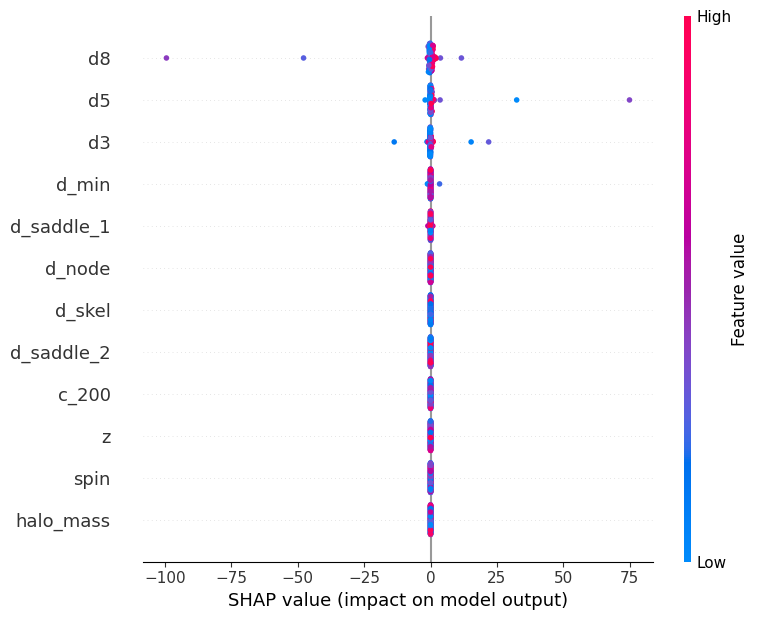

/tmp/ipykernel_695/4150755704.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(causal_shap_values, X_cs, feature_names=features, plot_type='bar', show=True)


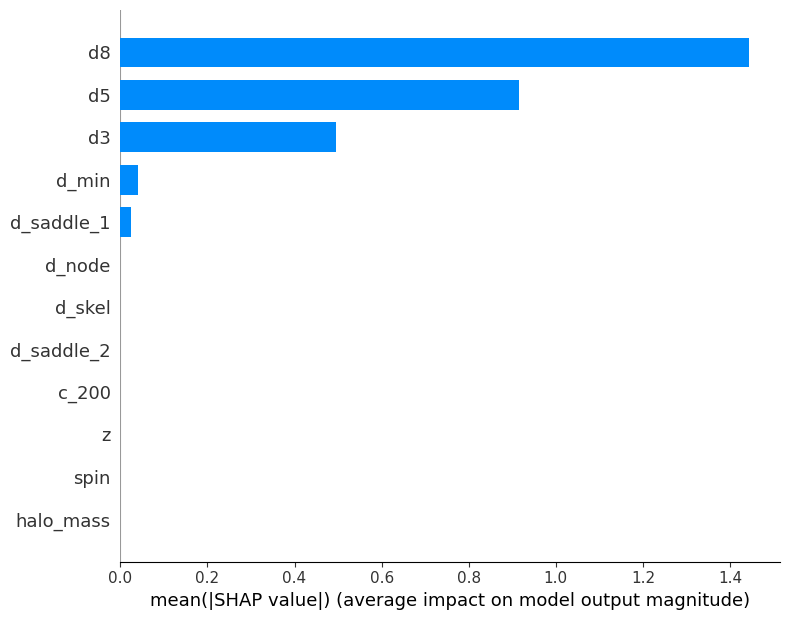

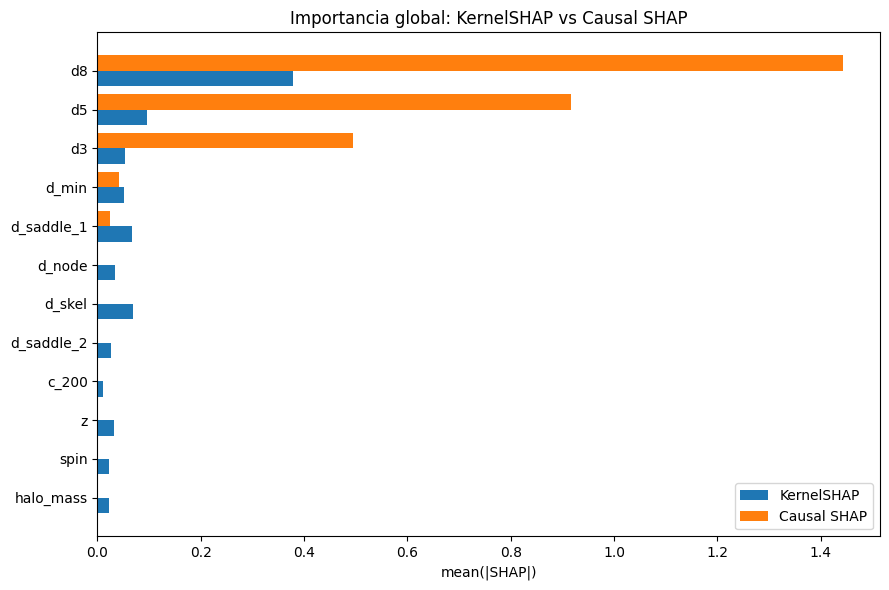

In [ ]:
# --- (1) Causal SHAP: importancia global (beeswarm + barras) ---
shap.summary_plot(causal_shap_values, X_cs, feature_names=features, show=True)
shap.summary_plot(causal_shap_values, X_cs, feature_names=features, plot_type='bar', show=True)

# --- (2) KernelSHAP vs Causal SHAP: importancia global media |SHAP| ---
# Features correlacionadas con b1 pero sin camino causal descubierto se descuentan.
kernel_imp = np.abs(shap_values).mean(0)
causal_imp = np.abs(causal_shap_values).mean(0)
order = np.argsort(causal_imp); yy = np.arange(n_features)
plt.figure(figsize=(9, 6))
plt.barh(yy - 0.2, kernel_imp[order], height=0.4, label='KernelSHAP')
plt.barh(yy + 0.2, causal_imp[order], height=0.4, label='Causal SHAP')
plt.yticks(yy, np.array(features)[order]); plt.xlabel('mean(|SHAP|)'); plt.legend()
plt.title('Importancia global: KernelSHAP vs Causal SHAP'); plt.tight_layout(); plt.show()

In [ ]:
# === Tabla comparativa de importancia (KernelSHAP vs Causal SHAP) + LaTeX dinámico ===
from IPython.display import display

# Notación tipo paper para cada feature
latex_name = {
    'halo_mass': r'M_{\rm vir}', 'd3': r'\delta_3', 'd5': r'\delta_5', 'd8': r'\delta_8',
    'c_200': r'c_{200}', 'z': r'z_{1/2}', 'spin': r'\lambda_{\rm halo}',
    'd_min': r'd_{\rm min}', 'd_node': r'd_{\rm node}', 'd_saddle_1': r'd_{\rm saddle1}',
    'd_saddle_2': r'd_{\rm saddle2}', 'd_skel': r'd_{\rm skel}',
}

# Importancia global = media de |SHAP| (los mismos valores del gráfico de barras comparativo)
kernel_imp = np.abs(shap_values).mean(0)
causal_imp = np.abs(causal_shap_values).mean(0)

def _ranked(imp):                       # features ordenadas de mayor a menor importancia
    return [(features[k], float(imp[k])) for k in np.argsort(imp)[::-1]]
k_rank, c_rank = _ranked(kernel_imp), _ranked(causal_imp)

# (1) Tabla legible
tabla_imp = pd.DataFrame({
    'Feature (KernelSHAP)':     [f for f, _ in k_rank],
    'Importance (KernelSHAP)':  [v for _, v in k_rank],
    'Feature (Causal SHAP)':    [f for f, _ in c_rank],
    'Importance (Causal SHAP)': [v for _, v in c_rank],
})
display(tabla_imp.round(6))

# (2) LaTeX dinámico (se regenera con los valores calculados; copia y pega en tu paper)
def _fmt(v):
    if v == 0:            return '0'
    if abs(v) >= 1e-3:    return f'{v:.3f}'
    m, e = f'{v:.1e}'.split('e')
    return rf'${m}\cdot10^{{{int(e)}}}$'

rows = [r'\begin{tabular}{cccc}', r'\toprule',
        r'\multicolumn{2}{c}{KernelSHAP} & \multicolumn{2}{c}{Causal SHAP} \\',
        r'Feature & Importance & Feature & Importance \\', r'\midrule']
for (kf, kv), (cf, cv) in zip(k_rank, c_rank):
    rows.append(f'${latex_name[kf]}$ & {_fmt(kv)} & ${latex_name[cf]}$ & {_fmt(cv)} \\\\')
rows += [r'\bottomrule', r'\end{tabular}']
latex_tabla = '\n'.join(rows)
print(latex_tabla)


,Feature (KernelSHAP),Importance (KernelSHAP),Feature (Causal SHAP),Importance (Causal SHAP)
0,d8,0.378956,d8,1.442676
1,d5,0.095863,d5,0.916039
2,d_skel,0.068137,d3,0.495445
3,d_saddle_1,0.066682,d_min,0.041671
4,d3,0.053393,d_saddle_1,0.024281
5,d_min,0.052060,d_node,0.000000
6,d_node,0.034907,d_skel,0.000000
7,z,0.032570,d_saddle_2,0.000000
8,d_saddle_2,0.026664,c_200,0.000000
9,spin,0.023324,z,0.000000


\begin{tabular}{cccc}
\toprule
\multicolumn{2}{c}{KernelSHAP} & \multicolumn{2}{c}{Causal SHAP} \\
Feature & Importance & Feature & Importance \\
\midrule
$\delta_8$ & 0.379 & $\delta_8$ & 1.443 \\
$\delta_5$ & 0.096 & $\delta_5$ & 0.916 \\
$d_{\rm skel}$ & 0.068 & $\delta_3$ & 0.495 \\
$d_{\rm saddle1}$ & 0.067 & $d_{\rm min}$ & 0.042 \\
$\delta_3$ & 0.053 & $d_{\rm saddle1}$ & 0.024 \\
$d_{\rm min}$ & 0.052 & $d_{\rm node}$ & 0 \\
$d_{\rm node}$ & 0.035 & $d_{\rm skel}$ & 0 \\
$z_{1/2}$ & 0.033 & $d_{\rm saddle2}$ & 0 \\
$d_{\rm saddle2}$ & 0.027 & $c_{200}$ & 0 \\
$\lambda_{\rm halo}$ & 0.023 & $z_{1/2}$ & 0 \\
$M_{\rm vir}$ & 0.023 & $\lambda_{\rm halo}$ & 0 \\
$c_{200}$ & 0.010 & $M_{\rm vir}$ & 0 \\
\bottomrule
\end{tabular}
